# McLeod Pitch Method
The naïve approach to pitch detection for a musical instrument is to take the Fourier transform of the string vibration and identify the frequency bin with the highest peak. Unfortunately, stringed instruments have a peculiar characteristic in which the fundamental frequency of a pitch may not produce the largest peak or may not even be present. One way to overcome this issue is to use the autocorrelation function (ACF), which can determine the fundamental frequency of a signal even when it is missing.

The McLeod Pitch Method (MPM) is based on autocorrelation but replaces the standard ACF with the Normalised Square Difference Function (NSDF). The NSDF follows the same lag-structure as the ACF but is scaled to the range [–1, 1], which makes peak-thresholding far more robust.

The MPM contains three main stages:
1. Computing the NSDF.
2. Peak picking—Finding the lag ($\tau$) at which the NSDF’s greatest peak occurs.
3. Parabolic interpolation—Refine $\tau$ via parabolic interpolation to obtain sub-lag accuracy ($\tau + \Delta \tau$)

This $\tau + \Delta \tau$ can then be converted into a frequency.

See the paper in markdown here: docs/smarter_way_to_find_pitch.md

## 1. Computing the NSDF
In the paper the NSDF is derived as:
$$n'_t(\tau) = \frac{2\,r'_t(\tau)}{m'_t(\tau)}$$

Where $r'(\tau)$ is the ACF:
$$r'_t(\tau) = \sum_{j=t}^{t+W-1-\tau} x_j\,x_{j+\tau}$$
and $m'(\tau)$ is the Sum of Sqaures Function (SOSF):
$$m'_t(\tau)=\sum_{j = t}^{\,t + W - 1 - \tau}\bigl(x_j^2 + x_{j+\tau}^2\bigr)$$

First lets create a couple of test signals to run the algorithm on.

In [38]:
freq1 = 110
freq2 = 257
fs = 8e3
N = 1024

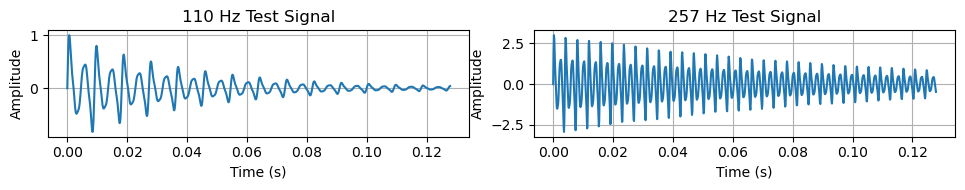

In [39]:
from utils import create_guitar_signal, plot_signal2

signal1, time1 = create_guitar_signal(fs, freq1, N, amplitude=1, decay_rate=25.0)
signal2, time2 = create_guitar_signal(fs, freq2, N, amplitude=3, decay_rate=10.0)
plot_signal2(
    signal1, signal2, 
    time1, time2,
    title1=f"{freq1} Hz Test Signal",
    title2=f"{freq2} Hz Test Signal",
    figsize=(10, 2)
)

The NSDF can be computed in two parts. 
1. The ACF in the numerator,
2. and the SOSF in the denominator.

Note, the ACF returns a signal of length $2N-1$, where $N =$ `len(signal)`. But this signal is symmetrical and we only require the right half. So to save computation the ACF is started with perfect overlap.

### 1.1 Computing ACF
The $t$ in the original equation refers to the starting position of a sliding window within a larger signal. Since we compute the ACF on pre-extracted windows (not the full signal), our window always starts at index 0, so we can set $t=0$. Furthermore, since we only need positive lags for pitch detection, our lag variable $\tau$ ranges from $\tau \in [0, W-1]$.
$$r'(\tau) = \sum_{j=0}^{W-1-\tau} x_j\,x_{j+\tau}$$

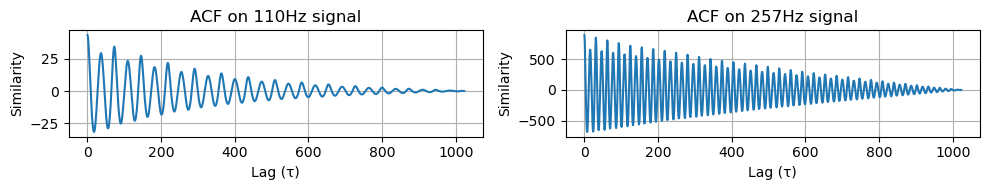

In [40]:
# input signal is assumed to be a prewindowed signal segment.
def ACF(signal):
    W = len(signal)
    lags = range(W)
    acf = list()
    for tau in lags:
        sum = 0
        for j in range(W - tau):
            x_j = signal[j]
            x_jτ = signal[j+tau]
            sum += x_j * x_jτ
        acf.append(sum)
    return acf, list(lags)

acf1, lags1 = ACF(signal1)
acf2, lags2 = ACF(signal2)
plot_signal2(
    acf1, acf2, 
    lags1, lags2,
    title1=f"ACF on {freq1}Hz signal",
    title2=f"ACF on {freq2}Hz signal",
    ylabel="Similarity",
    figsize=(10, 2),
    xlabel="Lag (τ)"
)

In an autocorrelation plot the x-axis is lag ($\tau$) and the y-axis is similarity. The point at $\tau = 0$ is always at max because a signal is perfectly correlated with itself, so it is ignored when estimating pitch. The first prominent peak after $\tau = 0$  occurs when the shifted signal aligns with the next repetition of the waveform; its position in samples equals one period. Converting that lag to seconds $\frac{\tau}{f_s}$  and taking its reciprocal gives the fundamental frequency: $f_0=\frac{f_s}{\tau_{peak}}$. Subsequent peaks appear at integer multiples of this lag, while their heights gradually diminish because fewer samples overlap as the shift grows.

Notice that the ACF trace on the right reaches much higher values than the one on the left. That is simply because signal 2 has a larger amplitude. At $\tau = 0$ the signal overlaps itself exactly, so $\text{ACF}[0]$ equals the sum of the squares of all samples, hence it scales with the signal’s energy. Autocorrelation is therefore very sensitive to input amplitude. Using a fixed threshold to pick “strong” peaks works poorly when two signals differ greatly in level, because their similarity scores lie on completely different scales.

What the MPM does is uses the SOSF to normalise ACF trace, making thresholding much simpler.

### 1.2 Computing the SOSF
Similiar to the ACF, except the elements are sqaured and added.
$$m'(\tau)=\sum_{j = 0}^{W - 1 - \tau}\bigl(x_j^2 + x_{j+\tau}^2\bigr)$$

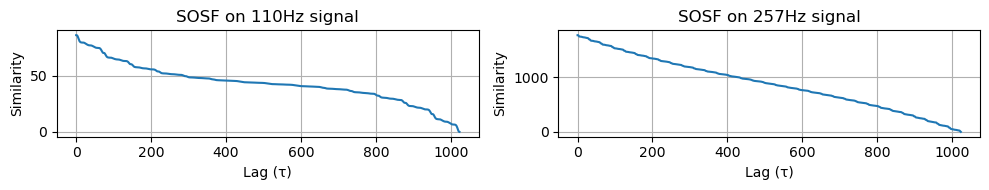

In [41]:
def SOSF(signal):
    W = len(signal)
    lags = range(W)
    sosf = list()
    for tau in lags:
        sum = 0
        for j in range(W - tau):
            x_j = signal[j]
            x_jτ = signal[j+tau]
            sum += (x_j*x_j +  x_jτ*x_jτ)
        sosf.append(sum)
    return sosf, list(lags)

sosf1, lags1 = SOSF(signal1)
sosf2, lags2 = SOSF(signal2)
plot_signal2(
    sosf1, sosf2, 
    lags1, lags2,
    title1=f"SOSF on {freq1}Hz signal",
    title2=f"SOSF on {freq2}Hz signal",
    ylabel="Similarity",
    figsize=(10, 2),
    xlabel="Lag (τ)"
)

We can see that the SOSF decays in proportion to the ACF and that its initial value is twice that of the first lag in the ACF. This is becuase the first lag of the ACF is the sum of the square elements and the SOSF first lag is the twice the sum of the sqaured elements. Hence, in the NSDF formula $r'$ is scaled by 2.
The next step is to normalise the ACF by dividing it by the SOSF.

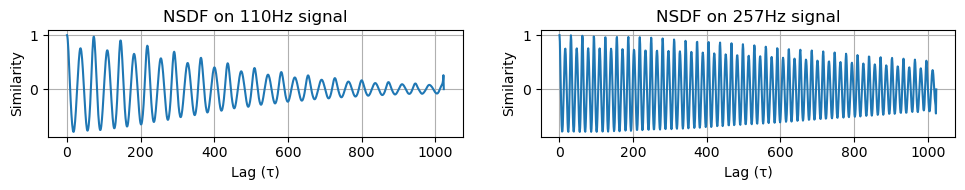

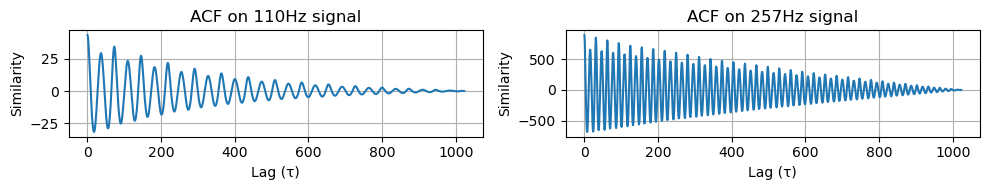

In [42]:
def NSDF(signal):
    W = len(signal)
    lags = range(W)
    nsdf = list()
    for tau in lags:
        acf_sum = 0
        sosf_sum = 0
        for j in range(W - tau):
            x_j = signal[j]
            x_jτ = signal[j+tau]
            acf_sum += x_j * x_jτ
            sosf_sum += (x_j*x_j +  x_jτ*x_jτ)

        nsdf.append(2*acf_sum / sosf_sum) # normalise here
    return nsdf, list(lags)

nsdf1, lags1 = NSDF(signal1)
nsdf2, lags2 = NSDF(signal2)

plot_signal2(
    nsdf1, nsdf2, 
    lags1, lags2,
    title1=f"NSDF on {freq1}Hz signal",
    title2=f"NSDF on {freq2}Hz signal",
    ylabel="Similarity",
    figsize=(10, 2),
    xlabel="Lag (τ)"
)
plot_signal2(
    acf1, acf2, 
    lags1, lags2,
    title1=f"ACF on {freq1}Hz signal",
    title2=f"ACF on {freq2}Hz signal",
    ylabel="Similarity",
    figsize=(10, 2),
    xlabel="Lag (τ)"
)

Now what we get is an ACF with less decay and bound to $[-1, 1]$.

## 2.0 Peak-picking
The next step is to find the second-largest peak (or the first, if you ignore the initial one). The lag associated with this peak gives the fundamental frequency of the signal.
This can be done with a simple linear scan, and you can apply a threshold to ensure you only process signals with strong periodicity.

In [43]:
def get_largest_peak_lag(signal, threshold):
    max_peak_val = 0
    max_peak_lag = 0
    zero_crossed = False
    
    for tau, val in enumerate(signal):
        if val < 0 and not zero_crossed:
            zero_crossed = True
            
        if zero_crossed and val > threshold:
            if val > max_peak_val:
                max_peak_val = val
                max_peak_lag = tau
                
    return max_peak_lag

max_tau1 = get_largest_peak_lag(nsdf1, 0)
max_tau2 = get_largest_peak_lag(nsdf2, 0)

print(f"f1 = (fs ÷ τ1) = {fs}/{max_tau1} = {fs/max_tau1:.3f} Hz")
print(f"f2 = (fs ÷ τ2) = {fs}/{max_tau2} = {fs/max_tau2:.3f} Hz")

f1 = (fs ÷ τ1) = 8000.0/73 = 109.589 Hz
f2 = (fs ÷ τ2) = 8000.0/31 = 258.065 Hz


## 3.0 Parabolic Interpolation
The above yields a reasonably accurate pitch estimate, but the true lag $\tau$ may lie between the discrete lag bins. To refine it, MPM fits a parabola through the peak bin and its two neighbours, then takes the vertex of that parabola as the sub-bin estimate of $\tau$.

In [44]:
import math
def parabolic_interpolation(x_pos, a, b, c):
    a = 20 * math.log10(a)
    b = 20 * math.log10(b)
    c = 20 * math.log10(c)
    
    delta_pos = 0.5 * (a - c) / (a - 2.0 * b + c)
    
    return x_pos + delta_pos

# For signal 1
a1, b1, c1 = nsdf1[max_tau1 - 1], nsdf1[max_tau1], nsdf1[max_tau1 + 1]
refined_tau1 = parabolic_interpolation(max_tau1, a1, b1, c1)
refined_freq1 = fs / refined_tau1

# For signal 2  
a2, b2, c2 = nsdf2[max_tau2 - 1], nsdf2[max_tau2], nsdf2[max_tau2 + 1]
refined_tau2 = parabolic_interpolation(max_tau2, a2, b2, c2)
refined_freq2 = fs / refined_tau2

print(
    f"Target: {freq1} Hz | f1: raw {fs/max_tau1:.3f} Hz ({(fs/max_tau1 - freq1)/freq1*100:+.2f}%) | "
    f"refined {fs/refined_tau1:.3f} Hz ({(fs/refined_tau1 - freq1)/freq1*100:+.2f}%)"
)
print(
    f"Target: {freq2} Hz | f2: raw {fs/max_tau2:.3f} Hz ({(fs/max_tau1 - freq1)/freq1*100:+.2f}%) | "
    f"refined {fs/refined_tau2:.3f} Hz ({(fs/refined_tau2 - freq2)/freq2*100:+.2f}%)"
)

Target: 110 Hz | f1: raw 109.589 Hz (-0.37%) | refined 109.990 Hz (-0.01%)
Target: 257 Hz | f2: raw 258.065 Hz (-0.37%) | refined 256.941 Hz (-0.02%)


As you can see, parabolic interpolation helps to really increase the accuracy.